<a href="https://colab.research.google.com/github/Ayomide-baga/CMP7005-PRAC1/blob/main/CMP7005_PRAC1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMP7005 Programming for Data Analysis — PRAC1
## From Data to Application Development
### Beijing Air Quality Analysis

**Student ID:** ST20349610  
**Module Leader:** aprasad@cardiffmet.ac.uk

## Research Context

Air pollution is one of the most pressing global public health challenges
of the 21st century. The World Health Organization estimates that ambient
air pollution contributes to millions of premature deaths annually, with
the greatest burden falling on rapidly developing urban centres (WHO, 2021).
Among the various pollutants monitored, PM2.5 — fine particulate matter
with a diameter of 2.5 micrometres or less — poses the most significant
health risk, as these particles are small enough to penetrate deep into
the lungs and enter the bloodstream, increasing the risk of cardiovascular
disease, respiratory illness, and lung cancer (Brauer et al., 2021).

Beijing, the capital of China, has experienced persistently poor air
quality over the past two decades, driven by rapid economic expansion,
heavy industrialisation, and growing vehicle emissions (Xu and Zhang, 2020).
In response, the Chinese government has implemented aggressive emission
control policies, including coal-to-gas conversion for residential heating,
stricter vehicle emission standards, and industrial relocation away from
the city centre (Li et al., 2024). Understanding whether these interventions
have had a measurable impact requires systematic, data-driven analysis of
long-term monitoring records.

Projects of this nature are critical for several reasons. First, they
transform raw monitoring data into actionable insights — identifying
which pollutants are most problematic, when and where pollution is worst,
and what factors drive it. Second, they enable evidence-based policy
evaluation — without rigorous analysis, it is impossible to determine
whether costly intervention measures are working. Third, predictive
modelling can support early warning systems, allowing authorities to
issue health advisories before pollution reaches dangerous levels.
Finally, interactive applications make these insights accessible to
non-technical stakeholders — policymakers, public health officials, and
citizens — who need clear, navigable information to make informed decisions.

This analysis uses hourly air quality data from four monitoring stations
across Beijing's urban-suburban gradient (March 2013 - February 2017) to
address the following research questions:

1. How do pollutant concentrations and AQI health categories differ
   between urban (Dongsi, Tiantan) and suburban (Dingling, Huairou)
   stations, and is this gradient consistent across seasons and times
   of day?

2. What meteorological and temporal factors - including wind speed,
   temperature, season, and hour of day - most strongly influence
   PM2.5 variability, and do these drivers differ between urban and
   suburban environments?

3. Has Beijing's air quality measurably improved over the 2013–2017
   period in response to emission control policies, and which
   pollutants show the greatest change?

4. Can PM2.5 concentrations be reliably predicted from co-pollutant
   and meteorological measurements using machine learning, and which
   features are most important for prediction accuracy?

These questions inform every stage of the analysis — from station
selection (Task 1), through exploratory analysis (Task 2), to
predictive modelling (Task 3) and the interactive application (Task 4).

### Dataset Overview

This analysis uses hourly air quality data from the Beijing Multi-Site
Air Quality dataset, collected from nationally controlled monitoring
stations between 1 March 2013 and 28 February 2017. Each record contains
six pollutant measurements (PM2.5, PM10, SO2, NO2, CO, O3) and five
meteorological variables (temperature, pressure, dew point, rainfall,
wind speed), along with wind direction and station identifier. Four
stations were selected - two urban (Dongsi, Tiantan) and two suburban
(Dingling, Huairou) - to enable spatial comparison across Beijing's
urban-suburban gradient.

## Task 1: Data Selection & Handling

### 1.1 Station Selection

For this analysis, **two urban (inner)** and **two suburban (outer)** monitoring stations were selected from Beijing's 12 nationally controlled air quality monitoring sites.

**Urban stations selected: Dongsi and Tiantan**  
**Suburban stations selected: Dingling and Huairou**

Xu and Zhang (2020) classify eight of the twelve Beijing monitoring stations as urban (Aotizhongxin, Dongsi, Guanyuan, Nongzhanguan, Tiantan, Wanshouxigong, Gucheng, and Haidian) and four as suburban (Changping, Dingling, Huairou, and Shunyi).

**Dongsi** is located in Beijing's Dongcheng District within the capital core zone (Z4), surrounded by dense residential neighbourhoods and heavy traffic, making it highly representative of inner-city pollution (Batterman et al., 2016).

**Tiantan** (Temple of Heaven) sits in the southern urban area, capturing pollution from local traffic and regional transport from the industrialised south (Guo et al., 2019).

**Dingling** is classified as a background/contrast station in a mountainous, forested area far from urban emissions (Batterman et al., 2016).

**Huairou** lies within the ecological conservation zone, representing the cleanest conditions among the 12 stations (Batterman et al., 2016).

This selection enables comparison across the urban–suburban gradient.

### 1.2 Setting Up the Environment

In [1]:
# Importing the necessary libraries for data analysis
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [2]:
! git config --global user.name "Ayomide-baga"
! git config --global user.email "bamigbopaayomide@gmail.com"

In [3]:
username = "Ayomide-baga"
repo = "CMP7005-PRAC1"

In [4]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'CMP7005-PRAC1'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 2.77 MiB | 4.72 MiB/s, done.


In [5]:
%cd {repo}

/content/CMP7005-PRAC1


In [6]:
%ls

PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Tiantan_20130301-20170228.csv
README.md


### 1.3 Loading and Merging the Datasets

In [7]:
# Load all station CSV files from the repository
city_files = glob.glob("*.csv")

dataframes = []
for file_name in city_files:
    city_df = pd.read_csv(file_name)
    dataframes.append(city_df)
    print(f"Loaded: {file_name}")

# Merge into a single unified dataset
df = pd.concat(dataframes, ignore_index=True)

# Confirmation
print(f"\nSUCCESS: Combined {len(city_files)} city files into one file with {len(df)} total rows")
print(f"Columns: {df.shape[1]}")
print(f"Stations: {df['station'].unique()}")

Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Tiantan_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv

SUCCESS: Combined 4 city files into one file with 140256 total rows
Columns: 18
Stations: ['Dongsi' 'Tiantan' 'Dingling' 'Huairou']


In [8]:
# Create a proper datetime column from individual time components
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Set as index for time-series analysis
df.set_index('datetime', inplace=True)

# Verify the date range and structure
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nRecords per station:")
print(df['station'].value_counts())
df.head()

Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00

Records per station:
station
Dongsi      35064
Tiantan     35064
Dingling    35064
Huairou     35064
Name: count, dtype: int64


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
2013-03-01 01:00:00,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2013-03-01 02:00:00,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
2013-03-01 03:00:00,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
2013-03-01 04:00:00,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [9]:
# Save merged dataset with datetime index
df.to_csv('merged_air_quality.csv')
print("Merged dataset saved as 'merged_air_quality.csv'")

Merged dataset saved as 'merged_air_quality.csv'


### 1.4 Summary

Four station datasets (Dongsi, Tiantan, Dingling, and Huairou) were successfully loaded and merged into a single unified DataFrame containing 140,256 rows and 18 columns, covering the period from 1 March 2013 to 28 February 2017. Each station contributes 35,064 hourly records. A datetime index was created from the individual year, month, day, and hour columns to facilitate time-series analysis. Station identifiers are preserved in the 'station' column to enable inter-station comparisons throughout the analysis. Some missing values are visible in the initial inspection and will be addressed in Task 2.

## Task 2: Exploratory Data Analysis (EDA)
### 2.1 Data Understanding

In [10]:
# Number of rows and columns
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Column names and data types
print("Column descriptions and data types:")
print(df.dtypes)

Dataset shape: 140256 rows, 18 columns

Column descriptions and data types:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object


In [11]:
# Detailed dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    137097 non-null  float64
 6   PM10     137673 non-null  float64
 7   SO2      136765 non-null  float64
 8   NO2      135038 non-null  float64
 9   CO       132499 non-null  float64
 10  O3       136384 non-null  float64
 11  TEMP     140112 non-null  float64
 12  PRES     140113 non-null  float64
 13  DEWP     140110 non-null  float64
 14  RAIN     140110 non-null  float64
 15  wd       139658 non-null  object 
 16  WSPM     140136 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 20.3+ MB


In [ ]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
2013-03-01 01:00:00,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2013-03-01 02:00:00,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
2013-03-01 03:00:00,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
2013-03-01 04:00:00,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [ ]:
df.tail()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2017-02-28 19:00:00,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
2017-02-28 20:00:00,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
2017-02-28 21:00:00,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
2017-02-28 22:00:00,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou
2017-02-28 23:00:00,35064,2017,2,28,23,11.0,20.0,2.0,27.0,400.0,77.0,6.7,1009.3,-13.6,0.0,NE,1.9,Huairou


In [12]:
# Statistical summary of numerical columns
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137097.000000,137673.000000,136765.000000,135038.000000,132499.000000,136384.000000,140112.000000,140113.000000,140110.000000,140110.000000,140136.000000
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.008598,97.999255,14.197895,41.772859,1137.793764,60.366923,13.368759,1010.114517,2.159931,0.064086,1.806885
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.468402,88.648097,19.734570,32.142645,1064.570208,56.640642,11.521420,10.482069,13.879616,0.794380,1.271235
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,18.000000,32.000000,2.000000,17.000000,400.000000,16.000000,3.000000,1001.700000,-9.400000,0.000000,1.000000
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,51.000000,75.000000,6.000000,34.000000,800.000000,50.000000,14.400000,1009.800000,2.600000,0.000000,1.400000
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,106.000000,136.000000,17.000000,60.000000,1400.000000,84.000000,23.100000,1018.300000,14.900000,0.000000,2.300000
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,993.000000,315.000000,258.000000,10000.000000,1071.000000,41.400000,1042.000000,29.100000,52.100000,12.900000


#### Interpretation — Statistical Summary

The statistical summary reveals several important characteristics:

- **PM2.5** has a mean of 76.0 µg/m³ but a median of only 51.0 µg/m³. This large gap confirms a right-skewed distribution where occasional extreme pollution episodes pull the mean upward. The maximum of 881 µg/m³ represents severe pollution events far exceeding WHO guidelines (15 µg/m³ annual mean).

- **CO** shows a maximum of 10,000 µg/m³, which is disproportionately large relative to the 75th percentile (1,400 µg/m³). These extreme values may represent measurement anomalies or genuine industrial emission events and warrant monitoring during modelling.

- **Temperature** ranges from -19.9°C to 41.4°C with a standard deviation of 11.5°C, reflecting Beijing's continental climate with extreme seasonal variation. This wide range is expected to influence pollutant behaviour significantly.

- **Rainfall** has a mean of only 0.064 mm/hour with a 75th percentile of 0, confirming that the vast majority of hours are dry — consistent with Beijing's semi-arid climate.

#### Column Descriptions

| Column | Description | Unit | Type |
|--------|-------------|------|------|
| year, month, day, hour | Timestamp components | - | Temporal |
| PM2.5 | Fine particulate matter (≤2.5µm diameter) | µg/m³ | Pollutant |
| PM10 | Coarse particulate matter (≤10µm diameter) | µg/m³ | Pollutant |
| SO2 | Sulphur dioxide | µg/m³ | Pollutant |
| NO2 | Nitrogen dioxide | µg/m³ | Pollutant |
| CO | Carbon monoxide | µg/m³ | Pollutant |
| O3 | Ozone | µg/m³ | Pollutant |
| TEMP | Temperature | °C | Meteorological |
| PRES | Atmospheric pressure | hPa | Meteorological |
| DEWP | Dew point temperature | °C | Meteorological |
| RAIN | Hourly rainfall | mm | Meteorological |
| WSPM | Wind speed | m/s | Meteorological |
| wd | Wind direction | - | Meteorological |
| station | Monitoring station name | - | Identifier |
| No | Row number per station | - | Identifier |

In [18]:
# Skewness analysis — quantify distribution asymmetry
numerical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                  'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
skewness = df[numerical_cols].skew().round(2)
kurtosis = df[numerical_cols].kurtosis().round(2)

skew_table = pd.DataFrame({'Skewness': skewness, 'Kurtosis': kurtosis})
skew_table['Distribution'] = skew_table['Skewness'].apply(
    lambda x: 'Right-skewed' if x > 1 else ('Left-skewed' if x < -1 else 'Approximately symmetric')
)
print("Distribution Shape Analysis:\n")
print(skew_table)

Distribution Shape Analysis:

       Skewness  Kurtosis             Distribution
PM2.5      2.01      5.87             Right-skewed
PM10       1.99      6.95             Right-skewed
SO2        3.13     14.58             Right-skewed
NO2        1.20      1.66             Right-skewed
CO         2.67     10.83             Right-skewed
O3         2.05     14.15             Right-skewed
TEMP      -0.11     -1.13  Approximately symmetric
PRES       0.10     -0.81  Approximately symmetric
DEWP      -0.17     -1.15  Approximately symmetric
RAIN      27.65   1056.02             Right-skewed
WSPM       1.72      3.96             Right-skewed


#### Interpretation — Distribution Shape and Outliers

**Skewness:** All six pollutants are positively skewed, confirming the
right-tailed distributions observed in the histograms. RAIN shows the
highest skewness, reflecting its sparse, event-driven nature. Temperature
and pressure are approximately symmetric, consistent with their seasonal
oscillation around central values.

**Outliers:** The IQR method reveals that all pollutants contain
significant numbers of outliers in the upper tail. These are not
measurement errors — they represent genuine extreme pollution episodes
that are characteristic of Beijing's air quality. Removing them would
distort the analysis by eliminating the very events that make air quality
monitoring critical. They will be retained throughout the analysis but
monitored for their impact on model performance in Task 3.

In [19]:
# Outlier detection using IQR method
print("Outlier Count (values beyond 1.5× IQR):\n")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    pct = 100 * outliers / df[col].notna().sum()
    print(f"  {col:>6}: {outliers:,} outliers ({pct:.1f}%)")

Outlier Count (values beyond 1.5× IQR):

   PM2.5: 6,558 outliers (4.8%)
    PM10: 5,006 outliers (3.6%)
     SO2: 12,254 outliers (9.0%)
     NO2: 2,878 outliers (2.1%)
      CO: 7,849 outliers (5.9%)
      O3: 5,687 outliers (4.2%)
    TEMP: 0 outliers (0.0%)
    PRES: 0 outliers (0.0%)
    DEWP: 0 outliers (0.0%)
    RAIN: 5,583 outliers (4.0%)
    WSPM: 8,076 outliers (5.8%)


In [15]:
# Missing values analysis
def missing_values_table(dataframe):
    mis_val = dataframe.isnull().sum()
    mis_val_percent = 100 * mis_val / len(dataframe)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)
    print(f"Total columns: {dataframe.shape[1]}")
    print(f"Columns with missing values: {mis_val_table[mis_val_table['Missing Values'] > 0].shape[0]}")
    return mis_val_table

missing_values_table(df)

Total columns: 18
Columns with missing values: 12


,Missing Values,% of Total Values
CO,7757,5.530601
NO2,5218,3.720340
O3,3872,2.760666
SO2,3491,2.489020
PM2.5,3159,2.252310
PM10,2583,1.841632
wd,598,0.426363
RAIN,146,0.104095
DEWP,146,0.104095
TEMP,144,0.102669


In [16]:
# Missing values per station
print("Missing values by station (key pollutants):\n")
for station in df['station'].unique():
    station_df = df[df['station'] == station]
    missing = station_df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].isnull().sum()
    print(f"--- {station} ---")
    print(missing)
    print()

Missing values by station (key pollutants):

--- Dongsi ---
PM2.5     750
PM10      553
SO2       663
NO2      1601
CO       3197
O3        664
dtype: int64

--- Tiantan ---
PM2.5     677
PM10      597
SO2      1118
NO2       744
CO       1126
O3        843
dtype: int64

--- Dingling ---
PM2.5     779
PM10      656
SO2       730
NO2      1234
CO       2012
O3       1214
dtype: int64

--- Huairou ---
PM2.5     953
PM10      777
SO2       980
NO2      1639
CO       1422
O3       1151
dtype: int64



#### Interpretation — Missing Values

**Overall:** CO has the highest missing rate (5.53%), followed by NO2 (3.72%), O3 (2.76%), and SO2 (2.49%). PM2.5 and PM10 have relatively low missing rates (2.25% and 1.84%). Meteorological variables (TEMP, PRES, DEWP, RAIN, WSPM) have minimal missing data (<0.11%). No missing values exist in time component columns or station identifiers.

**Station-Level Patterns:** Dongsi has the highest CO missingness (3,197 records, ~9.1% of its data), suggesting extended periods of instrument downtime at this urban station. Huairou shows the most PM2.5 gaps (953 records), while Dingling has the highest O3 missingness (1,214 records). Tiantan has the most evenly distributed missing values across pollutants.

These patterns suggest station-specific instrument failures rather than systematic data collection issues. The relatively low overall missing rates (all below 10%) mean imputation is appropriate and unlikely to introduce significant bias.

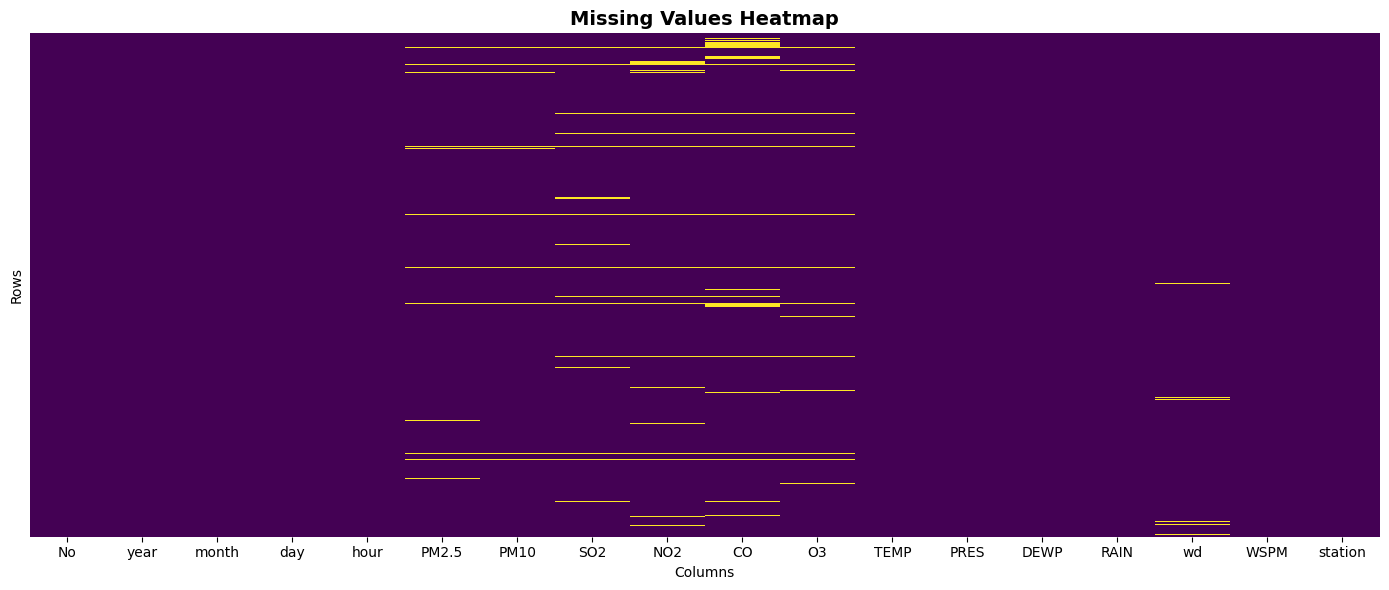

In [17]:
# Visualise missing values pattern across the dataset
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

#### Interpretation — Missing Values Heatmap

The heatmap provides a visual overview of data completeness across the entire dataset. Yellow lines indicate missing values. The pattern shows that missing data occurs in scattered clusters rather than continuous blocks, supporting the use of forward/backward fill imputation which relies on adjacent values being present. The pollutant columns (PM2.5 through O3) show visibly more yellow than the meteorological columns (TEMP through WSPM), confirming that pollutant sensors experienced more downtime than weather instruments.